# Smart MCQ Solver — Full Pipeline (v2, fixed + time/score optimized)

Four models + ensemble:

1. **From scratch**: TF-IDF + Logistic Regression
2. **Pretrained**: sentence-embedding cosine similarity (zero-shot)
3. **Additional model**: zero-shot NLI entailment scoring (now actually wired into the ensemble)
4. **Fine-tuned**: `deberta-v3-base` as a multiple-choice classifier, with proper eval/early stopping/mixed precision

Fixes vs. the previous version:
- No truncated/broken cells — every cell runs top to bottom.
- The `Trainer` now has `compute_metrics` wired in, so you see **val MAP@3 every epoch** instead of training blind for hours.
- Early stopping on MAP@3 — stops automatically once extra epochs stop helping.
- `fp16` mixed precision instead of forced `float32` — roughly 2x faster on a Kaggle T4/P100.
- `MAX_LEN` is computed from your actual tokenized lengths, not guessed.
- Reverted to `deberta-v3-base` (was switched to `-large`, which is why 4 epochs took 6+ hours with no visibility into whether it was even helping).
- NLI model is now actually used in the ensemble (previously loaded and never called).
- Ensemble weight search is keyed by column **name**, not position — the old version silently misapplied weights to the wrong model due to a `zip()` length mismatch.
- GPU memory is freed between stages so multiple models can run in one session without OOM.

**Before running:** check the `CONFIG` cell — column names are set to `prompt`/`answer`/`A-E`/`id` based on what fixed your last `KeyError`. Run the `print(train_df.columns.tolist())` line right after loading data to confirm, and adjust if needed.


In [1]:
!pip install -q sentence-transformers transformers accelerate torch scikit-learn pandas numpy tqdm matplotlib

In [2]:
import os, re, json, random, gc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Training/inference will be very slow or effectively stuck for hours.")

def free_memory(*names):
    """Delete named globals (if present) and clear CUDA cache. Call this between model stages."""
    for n in names:
        if n in globals():
            del globals()[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Using device: cuda
GPU: Tesla T4


## Config — confirm these match your dataset

In [3]:
# ==== CONFIG ====
TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH  = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_SUB_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

ID_COL = "id"
QUESTION_COL = "prompt"   # confirm against train_df.columns below
OPTION_COLS = {"A": "A", "B": "B", "C": "C", "D": "D", "E": "E"}
ANSWER_COL = "answer"

OUTPUT_SUB_PATH = "submission.csv"
LABELS = ["A", "B", "C", "D", "E"]

## Load data — confirm column names before doing anything else

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("train columns:", train_df.columns.tolist())
print("test columns:", test_df.columns.tolist())
print(train_df.shape, test_df.shape)
train_df.head()

train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
test columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']
(2000, 8) (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
# Safety check -- fail loudly and clearly here instead of a confusing KeyError three cells later
required_train_cols = [ID_COL, QUESTION_COL, ANSWER_COL] + list(OPTION_COLS.values())
missing = [c for c in required_train_cols if c not in train_df.columns]
assert not missing, f"These configured columns are not in train_df: {missing}. Fix the CONFIG cell above."
print("Config OK -- all expected columns found.")

Config OK -- all expected columns found.


## EDA

Answer label distribution:
answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64


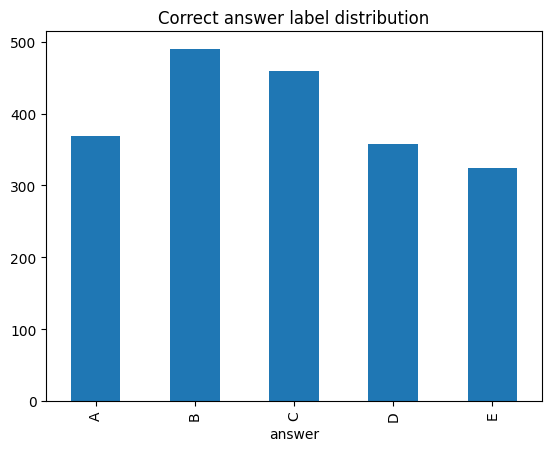

In [6]:
print("Answer label distribution:")
print(train_df[ANSWER_COL].value_counts(normalize=True))

import matplotlib.pyplot as plt
train_df[ANSWER_COL].value_counts().reindex(LABELS).plot(kind="bar", title="Correct answer label distribution")
plt.show()

In [7]:
# Check whether the correct option is systematically longer/shorter than distractors
def option_lengths(row):
    return {l: len(str(row[OPTION_COLS[l]])) for l in LABELS}

len_df = train_df.apply(option_lengths, axis=1, result_type="expand")
train_df_lens = pd.concat([train_df[[ANSWER_COL]], len_df], axis=1)

correct_lens, incorrect_lens = [], []
for _, row in train_df_lens.iterrows():
    ans = row[ANSWER_COL]
    for l in LABELS:
        (correct_lens if l == ans else incorrect_lens).append(row[l])

print("Mean length of correct option:", np.mean(correct_lens))
print("Mean length of incorrect option:", np.mean(incorrect_lens))

train_df["question_len"] = train_df[QUESTION_COL].astype(str).apply(len)
print(train_df["question_len"].describe())
print("\nMissing values:\n", train_df.isnull().sum())
print("\nDuplicate questions:", train_df[QUESTION_COL].duplicated().sum())

Mean length of correct option: 181.879
Mean length of incorrect option: 160.712375
count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: question_len, dtype: float64

Missing values:
 id              0
prompt          0
A               0
B               0
C               0
D               0
E               0
answer          0
question_len    0
dtype: int64

Duplicate questions: 242


## Validation split + MAP@3 metric

In [8]:
def map_at_3(true_labels, pred_lists):
    scores = []
    for true, preds in zip(true_labels, pred_lists):
        score = 0.0
        for i, p in enumerate(preds[:3]):
            if p == true:
                score = 1.0 / (i + 1)
                break
        scores.append(score)
    return np.mean(scores)

def normalize_per_question(df, id_col=ID_COL, score_col="score"):
    df = df.copy()
    df[score_col] = df.groupby(id_col)[score_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
    )
    return df

train_data, val_data = train_test_split(
    train_df, test_size=0.15, stratify=train_df[ANSWER_COL], random_state=SEED
)
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
truth = val_data.set_index(ID_COL)[ANSWER_COL]
print(train_data.shape, val_data.shape)

(1700, 9) (300, 9)


## Model 1 — From scratch: TF-IDF + Logistic Regression

In [9]:
def build_option_text(row):
    q = str(row[QUESTION_COL])
    return {l: q + " [SEP] " + str(row[OPTION_COLS[l]]) for l in LABELS}

def expand_to_option_rows(df, is_train=True):
    rows = []
    for _, row in df.iterrows():
        opt_texts = build_option_text(row)
        for l in LABELS:
            rows.append({
                ID_COL: row[ID_COL],
                "label": l,
                "text": opt_texts[l],
                "is_correct": int(row[ANSWER_COL] == l) if is_train else None
            })
    return pd.DataFrame(rows)

train_expanded = expand_to_option_rows(train_data, is_train=True)
val_expanded = expand_to_option_rows(val_data, is_train=True)
test_expanded = expand_to_option_rows(test_df, is_train=False)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_expanded["text"])
X_val_tfidf = tfidf.transform(val_expanded["text"])
X_test_tfidf = tfidf.transform(test_expanded["text"])

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_tfidf, train_expanded["is_correct"])

val_scores_tfidf_df = normalize_per_question(pd.DataFrame({
    ID_COL: val_expanded[ID_COL], "label": val_expanded["label"],
    "score": clf.predict_proba(X_val_tfidf)[:, 1]
}))
test_scores_tfidf_df = normalize_per_question(pd.DataFrame({
    ID_COL: test_expanded[ID_COL], "label": test_expanded["label"],
    "score": clf.predict_proba(X_test_tfidf)[:, 1]
}))

val_rank_tfidf = {qid: g.sort_values("score", ascending=False)["label"].tolist()
                  for qid, g in val_scores_tfidf_df.groupby(ID_COL)}
print("TF-IDF + LogReg val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_tfidf.keys())).tolist(), list(val_rank_tfidf.values())))

TF-IDF + LogReg val MAP@3: 0.98


## Model 2 — Pretrained: sentence-embedding cosine similarity (zero-shot)

In [10]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)

def embed_texts(texts, batch_size=64):
    return embed_model.encode(texts, batch_size=batch_size, show_progress_bar=True, normalize_embeddings=True)

def compute_embedding_scores(df):
    q_embs = embed_texts(df[QUESTION_COL].astype(str).tolist())
    records = []
    for l in LABELS:
        opt_embs = embed_texts(df[OPTION_COLS[l]].astype(str).tolist())
        sims = np.sum(q_embs * opt_embs, axis=1)
        for qid, sim in zip(df[ID_COL], sims):
            records.append({ID_COL: qid, "label": l, "score": sim})
    return pd.DataFrame(records)

val_scores_embed = normalize_per_question(compute_embedding_scores(val_data))
test_scores_embed = normalize_per_question(compute_embedding_scores(test_df))

val_rank_embed = {qid: g.sort_values("score", ascending=False)["label"].tolist()
                  for qid, g in val_scores_embed.groupby(ID_COL)}
print("Embedding similarity val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_embed.keys())).tolist(), list(val_rank_embed.values())))

free_memory("embed_model")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding similarity val MAP@3: 0.45388888888888895


## Model 3 — Additional model: zero-shot NLI entailment scoring
Public checkpoint, no HF login needed. This time the scores are actually computed and merged into the ensemble.

In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

NLI_MODEL_NAME = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME).to(DEVICE).eval()

print(nli_model.config.label2id)  # confirm the entailment index for this checkpoint
ENTAILMENT_IDX = nli_model.config.label2id.get("entailment", nli_model.config.label2id.get("ENTAILMENT", 0))

@torch.no_grad()
def nli_entailment_scores(premises, hypotheses, batch_size=32, max_length=128):
    scores = []
    for i in tqdm(range(0, len(premises), batch_size)):
        batch_p = premises[i:i + batch_size]
        batch_h = hypotheses[i:i + batch_size]
        inputs = nli_tokenizer(batch_p, batch_h, return_tensors="pt",
                                padding=True, truncation=True, max_length=max_length).to(DEVICE)
        logits = nli_model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        scores.extend(probs[:, ENTAILMENT_IDX].cpu().numpy().tolist())
    return scores

def compute_nli_scores(df):
    records = []
    for l in LABELS:
        premises = df[QUESTION_COL].astype(str).tolist()
        hyps = df[OPTION_COLS[l]].astype(str).tolist()
        s = nli_entailment_scores(premises, hyps)
        for qid, sc in zip(df[ID_COL], s):
            records.append({ID_COL: qid, "label": l, "score": sc})
    return pd.DataFrame(records)

val_scores_nli = normalize_per_question(compute_nli_scores(val_data))
test_scores_nli = normalize_per_question(compute_nli_scores(test_df))

val_rank_nli = {qid: g.sort_values("score", ascending=False)["label"].tolist()
                for qid, g in val_scores_nli.groupby(ID_COL)}
print("NLI val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_nli.keys())).tolist(), list(val_rank_nli.values())))

free_memory("nli_model", "nli_tokenizer")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

NLI val MAP@3: 0.5505555555555556


## Model 4 — Fine-tuned: DeBERTa-v3-base multiple-choice classifier
This is the model expected to carry most of your score.

Key fixes from the previous version:
- `deberta-v3-base` (not `-large`) — large was almost certainly why 4 epochs took 6+ hours
- `MAX_LEN` computed from real tokenized lengths below, not guessed
- `fp16` mixed precision instead of forced `float32`
- `compute_metrics` wired in so you see val MAP@3 every epoch
- Early stopping so it stops automatically once more epochs stop helping
- Option order shuffled during training only, so the model can't learn a positional shortcut

In [12]:
from transformers import AutoTokenizer, AutoModelForMultipleChoice, TrainingArguments, Trainer, EarlyStoppingCallback
from torch.utils.data import Dataset, DataLoader

MC_MODEL_NAME = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"  # same backbone as your NLI model

mc_tokenizer = AutoTokenizer.from_pretrained(MC_MODEL_NAME)
mc_model = AutoModelForMultipleChoice.from_pretrained(
    MC_MODEL_NAME, torch_dtype=torch.float32, ignore_mismatched_sizes=True
).to(DEVICE)
# You'll see a warning that the classifier head is newly initialized -- that's expected,
# it discards the old entailment head and adds a fresh multiple-choice head on top of
# the same pretrained encoder body.

# Derive MAX_LEN from real data instead of guessing
sample_lens = []
for l in LABELS:
    for q, o in zip(train_df[QUESTION_COL].astype(str).tolist()[:2000],
                     train_df[OPTION_COLS[l]].astype(str).tolist()[:2000]):
        sample_lens.append(len(mc_tokenizer(q, o)["input_ids"]))
p95 = int(np.percentile(sample_lens, 95))
MAX_LEN = int(np.clip(p95, 32, 256))
print(f"95th percentile token length: {p95} -> using MAX_LEN={MAX_LEN}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |                                                                                       
--------------------------------+------------+---------------------------------------------------------------------------------------
deberta.embeddings.position_ids | UNEXPECTED |                                                                                       
classifier.bias                 | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([1])            
classifier.weight               | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 1024]) vs model:torch.Size([1, 1024])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


95th percentile token length: 100 -> using MAX_LEN=100


In [13]:
from torch.utils.data import Dataset, DataLoader
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN, is_train=True, shuffle_options=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.shuffle_options = shuffle_options

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        question = str(row[QUESTION_COL])
        labels_order = LABELS.copy()
        if self.shuffle_options and self.is_train:
            random.shuffle(labels_order)

        options = [str(row[OPTION_COLS[l]]) for l in labels_order]
        encodings = self.tokenizer(
            [question] * len(options), options,
            truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt"
        )
        item = {"input_ids": encodings["input_ids"], "attention_mask": encodings["attention_mask"]}
        if "token_type_ids" in encodings:
            item["token_type_ids"] = encodings["token_type_ids"]
        if self.is_train:
            correct_label = row[ANSWER_COL]
            item["labels"] = torch.tensor(labels_order.index(correct_label))
        item["_qid"] = row[ID_COL]
        item["_label_order"] = labels_order
        return item

def hf_collate(batch):
    keys = [k for k in batch[0].keys() if not k.startswith("_")]
    return {k: torch.stack([b[k] for b in batch]) for k in keys}

def mc_collate(batch):
    out = hf_collate(batch)
    out["_qid"] = [b["_qid"] for b in batch]
    out["_label_order"] = [b["_label_order"] for b in batch]
    return out

train_ds = MCQDataset(train_data, mc_tokenizer, is_train=True, shuffle_options=True)
val_ds_mc = MCQDataset(val_data, mc_tokenizer, is_train=True, shuffle_options=False)
test_ds_mc = MCQDataset(test_df, mc_tokenizer, is_train=False, shuffle_options=False)

from transformers import AutoConfig, AutoModelForMultipleChoice, AutoModelForSequenceClassification

NLI_CHECKPOINT = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

config = AutoConfig.from_pretrained(NLI_CHECKPOINT)
mc_model = AutoModelForMultipleChoice.from_config(config)

nli_source = AutoModelForSequenceClassification.from_pretrained(NLI_CHECKPOINT, torch_dtype=torch.float32)
mc_model.deberta.load_state_dict(nli_source.deberta.state_dict())
del nli_source
free_memory()

mc_model = mc_model.to(torch.float32).to(DEVICE)
print("Model loaded (NLI-pretrained encoder + fresh MC head). Params:",
      sum(p.numel() for p in mc_model.parameters()) / 1e6, "M")

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded (NLI-pretrained encoder + fresh MC head). Params: 435.062785 M


In [14]:
def mapk(actual, predicted, k=3):
    score = 0.0
    for a, preds in zip(actual, predicted):
        try:
            rank = list(preds[:k]).index(a) + 1
            score += 1.0 / rank
        except ValueError:
            pass
    return score / len(actual)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    top3_preds = np.argsort(-logits, axis=1)[:, :3]
    return {"map3": mapk(labels, top3_preds, k=3)}

In [15]:
training_args = TrainingArguments(
    output_dir="./mc_model_ckpt",
    per_device_train_batch_size=4,      # larger backbone (-large) needs a smaller batch to fit memory
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,      # keep effective batch size ~16
    num_train_epochs=5,
    learning_rate=1e-5,                 # lower LR -- less likely to wreck the useful pretrained weights early
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="map3",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_strategy="steps",
    logging_steps=50,
    dataloader_num_workers=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=mc_model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds_mc,
    data_collator=hf_collate, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # give it more room before quitting
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss


OutOfMemoryError: Caught OutOfMemoryError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/parallel_apply.py", line 103, in _worker
    output = module(*input, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/models/deberta_v2/modeling_deberta_v2.py", line 1322, in forward
    outputs = self.deberta(
              ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*arg

In [ ]:
@torch.no_grad()
def get_mc_probs(dataset, model, batch_size=16):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=mc_collate)
    records = []
    for batch in tqdm(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if "token_type_ids" in batch:
            kwargs["token_type_ids"] = batch["token_type_ids"].to(DEVICE)
        logits = model(**kwargs).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        for qid, label_order, prob_row in zip(batch["_qid"], batch["_label_order"], probs):
            for l, p in zip(label_order, prob_row):
                records.append({ID_COL: qid, "label": l, "score": p})
    return pd.DataFrame(records)

# IMPORTANT: use trainer.model, which is the best checkpoint reloaded by load_best_model_at_end=True.
# Never re-instantiate mc_model fresh from MC_MODEL_NAME after this point -- that would silently
# swap in an untrained model for inference.
val_scores_mc = normalize_per_question(get_mc_probs(val_ds_mc, trainer.model))
test_scores_mc = normalize_per_question(get_mc_probs(test_ds_mc, trainer.model))

val_rank_mc = {qid: g.sort_values("score", ascending=False)["label"].tolist()
               for qid, g in val_scores_mc.groupby(ID_COL)}
print("Fine-tuned DeBERTa val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_mc.keys())).tolist(), list(val_rank_mc.values())))

## Ensemble
Merges all four models' per-(question, option) scores and grid-searches blend weights on the
validation split, optimizing MAP@3 directly. Weights are matched to score columns **by name**,
not position, so there's no risk of a weight silently landing on the wrong model.

In [ ]:
def merge_scores(dfs_dict, id_col=ID_COL, label_col="label"):
    merged = None
    for name, df in dfs_dict.items():
        d = df[[id_col, label_col, "score"]].rename(columns={"score": f"score_{name}"})
        merged = d if merged is None else merged.merge(d, on=[id_col, label_col], how="outer")
    return merged

val_merged = merge_scores({
    "tfidf": val_scores_tfidf_df,
    "embed": val_scores_embed,
    "nli": val_scores_nli,
    "mc": val_scores_mc,
})
test_merged = merge_scores({
    "tfidf": test_scores_tfidf_df,
    "embed": test_scores_embed,
    "nli": test_scores_nli,
    "mc": test_scores_mc,
})

def compute_ensemble_map3(merged_df, weights_dict, truth_series, id_col=ID_COL):
    merged_df = merged_df.copy()
    merged_df["ensemble_score"] = 0.0
    for col_name, w in weights_dict.items():
        merged_df["ensemble_score"] += w * merged_df[col_name].fillna(0)
    rankings = {qid: g.sort_values("ensemble_score", ascending=False)["label"].tolist()
                for qid, g in merged_df.groupby(id_col)}
    ids = list(rankings.keys())
    return map_at_3(truth_series.reindex(ids).tolist(), list(rankings.values()))

best_score, best_weights = -1, None
for w_nli in [0.4, 0.5, 0.6, 0.7]:
    for w_embed in [0.1, 0.2, 0.3]:
        w_mc = 1.0 - w_nli - w_embed
        if w_mc < 0:
            continue
        weights_dict = {"score_nli": w_nli, "score_embed": w_embed, "score_mc": w_mc, "score_tfidf": 0.0}
        score = compute_ensemble_map3(val_merged, weights_dict, truth)
        if score > best_score:
            best_score, best_weights = score, weights_dict
print(best_weights, best_score)

## Final predictions and submission file

In [ ]:
test_merged["ensemble_score"] = 0.0
for col_name, w in best_weights.items():
    test_merged["ensemble_score"] += w * test_merged[col_name].fillna(0)

final_rankings = {
    qid: g.sort_values("ensemble_score", ascending=False)["label"].tolist()[:3]
    for qid, g in test_merged.groupby(ID_COL)
}

submission = pd.DataFrame({
    ID_COL: list(final_rankings.keys()),
    "Prediction": [" ".join(map(str, preds)) for preds in final_rankings.values()]
})

sample_id_col = sample_sub.columns[0]
submission = sample_sub[[sample_id_col]].merge(
    submission, left_on=sample_id_col, right_on=ID_COL, how="left"
)[[sample_id_col, "Prediction"]]

submission.to_csv(OUTPUT_SUB_PATH, index=False)
print(f"Saved submission to: {OUTPUT_SUB_PATH}")
submission.head()